In [ ]:
import requests
import pandas as pd
import os
import requests
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("EIA_API_KEY")

BASE_URL = "https://api.eia.gov/v2"

DATA_URL = (
    f"{BASE_URL}/electricity/rto/"
    "region-data/data/"
)

params = {
    "api_key": API_KEY,
    "frequency": "hourly",
    "data[0]": "value",

    # California ISO
    "facets[respondent][]": "CISO",

    # Actual demand
    "facets[type][]": "D",

    "start": "2025-08-01T00",
    "end": "2026-09-16T00",

    "sort[0][column]": "period",
    "sort[0][direction]": "asc",

    "offset": 0,
    "length": 5000
}

response = requests.get(
    DATA_URL,
    params=params,
    timeout=30
)

response.raise_for_status()

result = response.json()


print("Total rows:", result["response"]["total"])

result["response"]["data"][:5]

Total rows: 9865


[{'period': '2025-08-01T00',
  'respondent': 'CISO',
  'respondent-name': 'California Independent System Operator',
  'type': 'D',
  'type-name': 'Demand',
  'value': '31862',
  'value-units': 'megawatthours'},
 {'period': '2025-08-01T01',
  'respondent': 'CISO',
  'respondent-name': 'California Independent System Operator',
  'type': 'D',
  'type-name': 'Demand',
  'value': '33033',
  'value-units': 'megawatthours'},
 {'period': '2025-08-01T02',
  'respondent': 'CISO',
  'respondent-name': 'California Independent System Operator',
  'type': 'D',
  'type-name': 'Demand',
  'value': '34012',
  'value-units': 'megawatthours'},
 {'period': '2025-08-01T03',
  'respondent': 'CISO',
  'respondent-name': 'California Independent System Operator',
  'type': 'D',
  'type-name': 'Demand',
  'value': '35130',
  'value-units': 'megawatthours'},
 {'period': '2025-08-01T04',
  'respondent': 'CISO',
  'respondent-name': 'California Independent System Operator',
  'type': 'D',
  'type-name': 'Demand',


In [57]:
df = pd.DataFrame(
    result["response"]["data"]
)

df.head()

,period,respondent,respondent-name,type,type-name,value,value-units
0,2025-08-01T00,CISO,California Independent System Operator,D,Demand,31862,megawatthours
1,2025-08-01T01,CISO,California Independent System Operator,D,Demand,33033,megawatthours
2,2025-08-01T02,CISO,California Independent System Operator,D,Demand,34012,megawatthours
3,2025-08-01T03,CISO,California Independent System Operator,D,Demand,35130,megawatthours
4,2025-08-01T04,CISO,California Independent System Operator,D,Demand,35140,megawatthours


In [58]:
df.tail()

,period,respondent,respondent-name,type,type-name,value,value-units
4995,2026-02-25T03,CISO,California Independent System Operator,D,Demand,26763,megawatthours
4996,2026-02-25T04,CISO,California Independent System Operator,D,Demand,26173,megawatthours
4997,2026-02-25T05,CISO,California Independent System Operator,D,Demand,25429,megawatthours
4998,2026-02-25T06,CISO,California Independent System Operator,D,Demand,24736,megawatthours
4999,2026-02-25T07,CISO,California Independent System Operator,D,Demand,23438,megawatthours


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   period           5000 non-null   object
 1   respondent       5000 non-null   object
 2   respondent-name  5000 non-null   object
 3   type             5000 non-null   object
 4   type-name        5000 non-null   object
 5   value            5000 non-null   object
 6   value-units      5000 non-null   object
dtypes: object(7)
memory usage: 273.6+ KB


In [60]:
df["period"] = pd.to_datetime(
    df["period"],
    utc=True
)

df["value"] = pd.to_numeric(
    df["value"],
    errors="coerce"
)

df = (
    df
    .sort_values("period")
    .reset_index(drop=True)
)

In [61]:
df["gap_hours"] = (
    df["period"]
    .diff()
    .dt.total_seconds()
    / 3600
)

df["gap_hours"].value_counts().sort_index()

gap_hours
1.0    4999
Name: count, dtype: int64

In [62]:
print(
    "Duplicate timestamps:",
    df["period"].duplicated().sum()
)

Duplicate timestamps: 0


In [63]:
print(
    "Missing demand:",
    df["value"].isna().sum()
)

Missing demand: 0


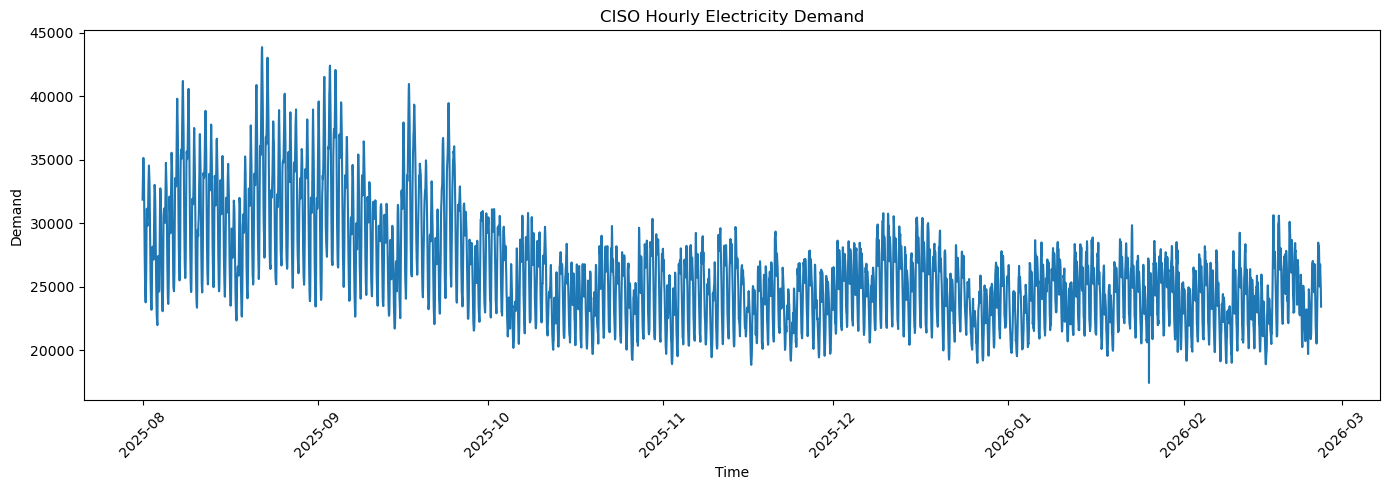

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    df["period"],
    df["value"]
)

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("CISO Hourly Electricity Demand")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
df["target_demand_1h"] = (
    df["value"].shift(-1)
)

In [66]:
params = {
    "api_key": API_KEY,
    "frequency": "hourly",
    "data[0]": "value",

    # California ISO
    "facets[respondent][]": "CISO",

    # Actual demand
    "facets[type][]": "D",

    "start": "2026-02-25T00",
    "end": "2026-09-16T00",

    "sort[0][column]": "period",
    "sort[0][direction]": "asc",

    "offset": 0,
    "length": 5000
}

response = requests.get(
    DATA_URL,
    params=params,
    timeout=30
)
result2 = response.json()

print("Total rows:", result2["response"]["total"])


Total rows: 4873


Duplicate timestamps: 0
Missing demand: 0


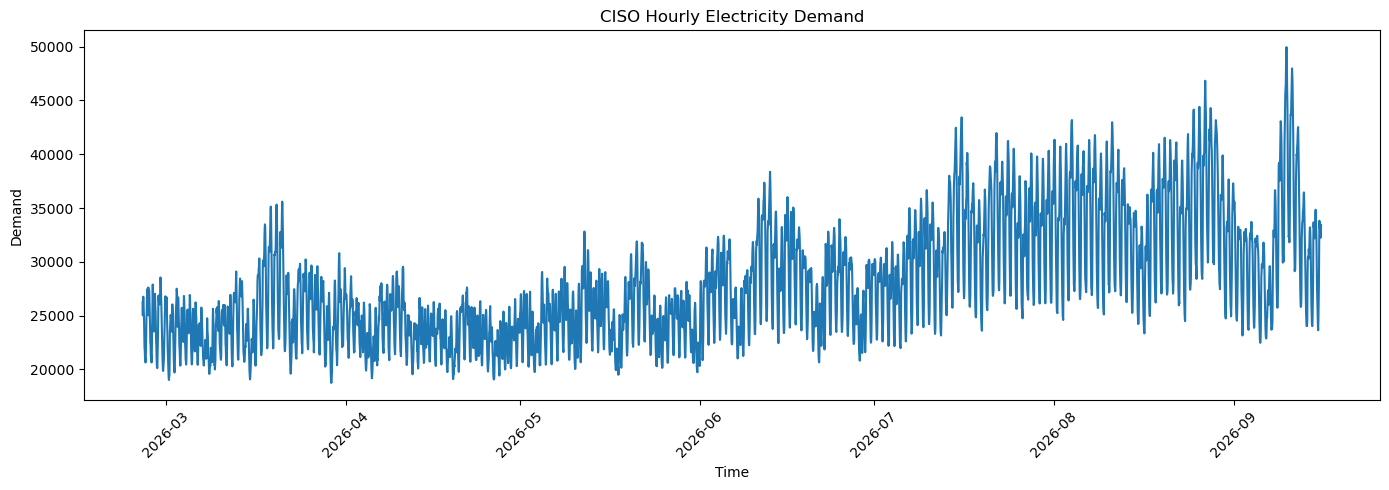

In [67]:
df2 = pd.DataFrame(
    result2["response"]["data"]
)

df2["period"] = pd.to_datetime(
    df2["period"],
    utc=True
)

df2["value"] = pd.to_numeric(
    df2["value"],
    errors="coerce"
)

df2 = (
    df2
    .sort_values("period")
    .reset_index(drop=True)
)


df2["target_demand_1h"] = (
    df2["value"].shift(-1)
)

df2["gap_hours"] = (
    df2["period"]
    .diff()
    .dt.total_seconds()
    / 3600
)


print(
    "Duplicate timestamps:",
    df2["period"].duplicated().sum()
)
print(
    "Missing demand:",
    df2["value"].isna().sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    df2["period"],
    df2["value"]
)

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("CISO Hourly Electricity Demand")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [68]:
df2.head(5)

,period,respondent,respondent-name,type,type-name,value,value-units,target_demand_1h,gap_hours
0,2026-02-25 00:00:00+00:00,CISO,California Independent System Operator,D,Demand,26262,megawatthours,25024.0,NaN
1,2026-02-25 01:00:00+00:00,CISO,California Independent System Operator,D,Demand,25024,megawatthours,26187.0,1.0
2,2026-02-25 02:00:00+00:00,CISO,California Independent System Operator,D,Demand,26187,megawatthours,26763.0,1.0
3,2026-02-25 03:00:00+00:00,CISO,California Independent System Operator,D,Demand,26763,megawatthours,26173.0,1.0
4,2026-02-25 04:00:00+00:00,CISO,California Independent System Operator,D,Demand,26173,megawatthours,25429.0,1.0


In [69]:
df2.tail(5)

,period,respondent,respondent-name,type,type-name,value,value-units,target_demand_1h,gap_hours
4868,2026-09-15 20:00:00+00:00,CISO,California Independent System Operator,D,Demand,33038,megawatthours,32815.0,1.0
4869,2026-09-15 21:00:00+00:00,CISO,California Independent System Operator,D,Demand,32815,megawatthours,32252.0,1.0
4870,2026-09-15 22:00:00+00:00,CISO,California Independent System Operator,D,Demand,32252,megawatthours,32661.0,1.0
4871,2026-09-15 23:00:00+00:00,CISO,California Independent System Operator,D,Demand,32661,megawatthours,33434.0,1.0
4872,2026-09-16 00:00:00+00:00,CISO,California Independent System Operator,D,Demand,33434,megawatthours,NaN,1.0


In [70]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4873 entries, 0 to 4872
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   period            4873 non-null   datetime64[ns, UTC]
 1   respondent        4873 non-null   object             
 2   respondent-name   4873 non-null   object             
 3   type              4873 non-null   object             
 4   type-name         4873 non-null   object             
 5   value             4873 non-null   int64              
 6   value-units       4873 non-null   object             
 7   target_demand_1h  4872 non-null   float64            
 8   gap_hours         4872 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(1), object(5)
memory usage: 342.8+ KB


In [76]:
full_df = pd.concat([df, df2], axis=0, ignore_index=True)
full_df = full_df.drop_duplicates()
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9867 entries, 0 to 9872
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   period            9867 non-null   datetime64[ns, UTC]
 1   respondent        9867 non-null   object             
 2   respondent-name   9867 non-null   object             
 3   type              9867 non-null   object             
 4   type-name         9867 non-null   object             
 5   value             9867 non-null   int64              
 6   value-units       9867 non-null   object             
 7   gap_hours         9865 non-null   float64            
 8   target_demand_1h  9865 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(1), object(5)
memory usage: 770.9+ KB


In [78]:
full_df.head(5)

,period,respondent,respondent-name,type,type-name,value,value-units,gap_hours,target_demand_1h
0,2025-08-01 00:00:00+00:00,CISO,California Independent System Operator,D,Demand,31862,megawatthours,NaN,33033.0
1,2025-08-01 01:00:00+00:00,CISO,California Independent System Operator,D,Demand,33033,megawatthours,1.0,34012.0
2,2025-08-01 02:00:00+00:00,CISO,California Independent System Operator,D,Demand,34012,megawatthours,1.0,35130.0
3,2025-08-01 03:00:00+00:00,CISO,California Independent System Operator,D,Demand,35130,megawatthours,1.0,35140.0
4,2025-08-01 04:00:00+00:00,CISO,California Independent System Operator,D,Demand,35140,megawatthours,1.0,34411.0


In [79]:
full_df

,period,respondent,respondent-name,type,type-name,value,value-units,gap_hours,target_demand_1h
0,2025-08-01 00:00:00+00:00,CISO,California Independent System Operator,D,Demand,31862,megawatthours,NaN,33033.0
1,2025-08-01 01:00:00+00:00,CISO,California Independent System Operator,D,Demand,33033,megawatthours,1.0,34012.0
2,2025-08-01 02:00:00+00:00,CISO,California Independent System Operator,D,Demand,34012,megawatthours,1.0,35130.0
3,2025-08-01 03:00:00+00:00,CISO,California Independent System Operator,D,Demand,35130,megawatthours,1.0,35140.0
4,2025-08-01 04:00:00+00:00,CISO,California Independent System Operator,D,Demand,35140,megawatthours,1.0,34411.0
...,...,...,...,...,...,...,...,...,...
9868,2026-09-15 20:00:00+00:00,CISO,California Independent System Operator,D,Demand,33038,megawatthours,1.0,32815.0
9869,2026-09-15 21:00:00+00:00,CISO,California Independent System Operator,D,Demand,32815,megawatthours,1.0,32252.0
9870,2026-09-15 22:00:00+00:00,CISO,California Independent System Operator,D,Demand,32252,megawatthours,1.0,32661.0
9871,2026-09-15 23:00:00+00:00,CISO,California Independent System Operator,D,Demand,32661,megawatthours,1.0,33434.0


In [80]:
full_df.tail()

,period,respondent,respondent-name,type,type-name,value,value-units,gap_hours,target_demand_1h
9868,2026-09-15 20:00:00+00:00,CISO,California Independent System Operator,D,Demand,33038,megawatthours,1.0,32815.0
9869,2026-09-15 21:00:00+00:00,CISO,California Independent System Operator,D,Demand,32815,megawatthours,1.0,32252.0
9870,2026-09-15 22:00:00+00:00,CISO,California Independent System Operator,D,Demand,32252,megawatthours,1.0,32661.0
9871,2026-09-15 23:00:00+00:00,CISO,California Independent System Operator,D,Demand,32661,megawatthours,1.0,33434.0
9872,2026-09-16 00:00:00+00:00,CISO,California Independent System Operator,D,Demand,33434,megawatthours,1.0,NaN


In [81]:
print(f"start period: {full_df['period'].iloc[0]}")
print(f"end period: {full_df['period'].iloc[-1]}")

start period: 2025-08-01 00:00:00+00:00
end period: 2026-09-16 00:00:00+00:00


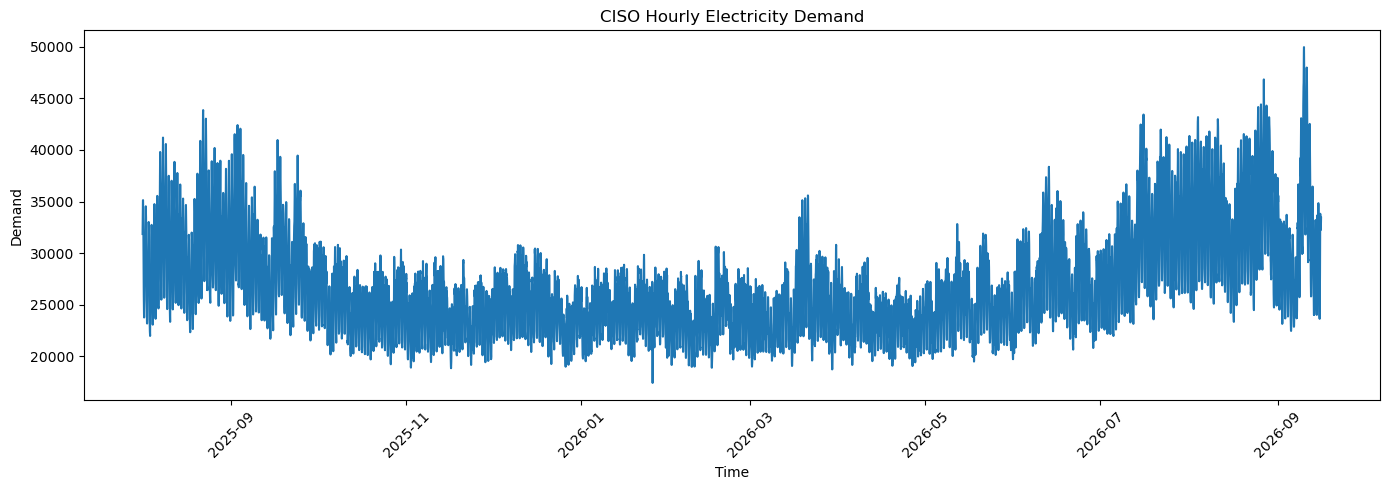

In [82]:
plt.figure(figsize=(14, 5))

plt.plot(
    full_df["period"],
    full_df["value"]
)

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("CISO Hourly Electricity Demand")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()